# Understanding and tuning the FinMultiTime next-day Transformer

This notebook explains **what each array means**, **when each input becomes available**, and **how to tune without selecting on the final evaluation period**. It predicts three probabilities:

$$p_t=(P(C^{SPY}_{t+1}>C^{SPY}_t),\;P(C^{QQQ}_{t+1}>C^{QQQ}_t),\;P(C^{IWM}_{t+1}>C^{IWM}_t))\in[0,1]^3.$$

Here $t$ is an ETF trading session after its close. A probability is not a trade recommendation. The default direction decision is `p >= 0.5`; probability quality is measured with Brier score, while threshold accuracy is reported separately. This notebook uses the real [FinMultiTime dataset](https://huggingface.co/datasets/Wenyan0110/Multimodal-Dataset-Image_Text_Table_TimeSeries-for-Financial-Time-Series-Forecasting) and local Alpaca-adjusted ETF daily closes.

## 1. Set up the cached dataset

Use the `Quant_ENV` kernel. The first run requires internet access and downloads the 483 MB price ZIP into the OS temporary cache. News and financial-table members are fetched by HTTP range; chart PNGs are fetched individually. Later runs reuse cached arrays. The FinMultiTime price archive stops at **2025-03-28**, so this notebook is a historical experiment rather than a current forecast.

In [1]:
from pathlib import Path
import sys, tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

here = Path.cwd()
if not (here / 'finmultitime_daily.py').exists():
    here = here / 'HF_Transformer'
sys.path.insert(0, str(here.resolve()))
from finmultitime_daily import (
    TARGETS, MultiModalTransformer, build_dataset, make_windows,
    train_and_replay, plot_accuracy,
)

target_dir = here.parent / 'SP500' / 'attention_data'
cache_dir = Path(tempfile.gettempdir()) / 'codex_finmultitime_source'
output_dir = here / 'finmultitime_tuning_outputs'
dataset = build_dataset(target_dir, cache_dir, start='2018-01-01', end='2025-03-28')
dates = pd.DatetimeIndex(pd.to_datetime(dataset['dates']))
print(f'{len(dates)} synchronized ETF sessions: {dates[0].date()} to {dates[-1].date()}')
print('All probabilities below will concern the next ETF close after the issue date.')

1820 synchronized ETF sessions: 2018-01-02 to 2025-03-28
All probabilities below will concern the next ETF close after the issue date.


## 2. Read the tensors before changing the model

| Key | One session contains | Shape |
|---|---|---|
| `price` | ETF price/volume features plus return breadth across all FinMultiTime ticker CSVs | `(sessions, 16)` |
| `news` | Signed hashed article-word vector plus article count and mean length | `(sessions, 34)` |
| `table` | Filed balance-sheet ratios and company coverage | `(sessions, 5)` |
| `image` | Pixels from completed half-year candlestick charts plus coverage | `(sessions, 433)` |
| `labels` | Whether next close exceeds current close for SPY, QQQ, IWM | `(sessions, 3)` |

The tensor dimensions are engineered representations of **actual source records**. Text uses a deterministic word hash, not a pretrained language model. The chart image is cropped and reduced to 12×12 RGB pixels, so fine visual detail is lost. The financial tables are summarized as ratios instead of passed as raw JSON. These choices make CPU experiments practical and are useful knobs for later research.

In [2]:
display(pd.DataFrame({
    'modality': ['price', 'news', 'table', 'image'],
    'shape': [str(dataset[key].shape) for key in ['price', 'news', 'table', 'image']],
    'nonzero session share': [float(np.any(dataset[key] != 0, axis=1).mean()) for key in ['price', 'news', 'table', 'image']],
}))
print('Source coverage: news symbols/articles =', dataset['news_counts'].tolist(),
      '| table symbols/usable filings =', dataset['table_counts'].tolist(),
      '| image symbols/completed charts =', dataset['image_counts'].tolist())
coverage = pd.DataFrame({
    'year': dates.year,
    'news': dataset['news'][:, -2] > 0,
    'table': dataset['table'][:, -1] > 0,
    'image': dataset['image'][:, -1] > 0,
}).groupby('year')[['news', 'table', 'image']].mean()
display(coverage.round(3))
print('Target label shape:', dataset['labels'].shape, '(zero means down/flat, not missing)')
if (coverage.news < .5).any():
    print('Low news coverage years:', coverage.index[coverage.news < .5].tolist())

,modality,shape,nonzero session share
0,price,"(1820, 16)",1.000000
1,news,"(1820, 34)",0.860989
2,table,"(1820, 5)",1.000000
3,image,"(1820, 433)",1.000000


Source coverage: news symbols/articles = [8, 59005] | table symbols/usable filings = [7, 171] | image symbols/completed charts = [9, 144]


,news,table,image
year,,,
2018,0.996,1.0,1.0
2019,1.000,1.0,1.0
2020,1.000,1.0,1.0
2021,1.000,1.0,1.0
2022,1.000,1.0,1.0
2023,0.968,1.0,1.0
2024,0.032,1.0,1.0
2025,1.000,1.0,1.0


Target label shape: (1820, 3) (zero means down/flat, not missing)
Low news coverage years: [2024]


**Coverage is not freshness.** Tables and images carry the latest known filing/chart forward, so their nonzero share can be 100% even when no new report or chart appeared that year. For the selected news symbols, the source JSONL files contain almost no 2024 records; the yearly table above shows the resulting gap. The model sees an explicit zero news vector/count on those sessions. This is a source-data limitation, not evidence that the market had no news. Treat 2024–2025 comparisons with that limitation in mind and verify coverage again if you change the symbol set.

### Timing rules and target alignment

- `price[t]` uses bars known at close `t`. The target is `close[t+1] > close[t]`.
- A news record with date `d` enters on the **first later ETF session**, because the archive has a date but no reliable intraday publication time.
- A table fact must have `filed <= filing_date` and `period_end <= filing_date`; it enters on the **first later ETF session**.
- A chart for a half-year enters only after that half-year ends. Its image file may have been generated later; exact chart publication dates and historical revisions are unavailable.
- Cross-sectional price breadth uses the snapshot's available ticker list, which is not a point-in-time index membership record. This can create survivorship bias.

The check below shows a single window: 40 feature sessions ending on the issue date, followed by one label session. There is no next-day bar in the model input.

In [3]:
window_example = 40
windows, y, issue_indices = make_windows(dataset, window=window_example)
example = min(1000, len(issue_indices)-1)
issue = issue_indices[example]
print('Window:', dates[issue-window_example+1].date(), 'through', dates[issue].date())
print('Forecast issued after:', dates[issue].date())
print('Outcome measured at:', dates[issue+1].date())
print('Observed next-day labels:', dict(zip(TARGETS, y[example].astype(int))))
print('One model batch shape:', {key: val[example:example+1].shape for key, val in windows.items()})
example_model = MultiModalTransformer({key: val.shape[-1] for key, val in windows.items()}, hidden=64, heads=4, layers=2)
print('Trainable parameters:', sum(p.numel() for p in example_model.parameters()))
del windows, y, example_model

Window: 2021-12-21 through 2022-02-16
Forecast issued after: 2022-02-16
Outcome measured at: 2022-02-17
Observed next-day labels: {'SPY': 0, 'QQQ': 0, 'IWM': 0}
One model batch shape: {'price': (1, 40, 16), 'news': (1, 40, 34), 'table': (1, 40, 5), 'image': (1, 40, 433)}
Trainable parameters: 131527


c:\ProgramData\Anaconda3\envs\Quant_ENV\Lib\site-packages\torch\nn\modules\transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


## 3. A defensible tuning timeline

We use **2018–2022 for initial fitting**, **2023 for model selection**, and **2024–2025 for a forward evaluation**. Each validation/evaluation prediction is recorded before the next-day label is used for one online gradient update. For tuning, the run is truncated at the end of 2023, so no 2024–2025 arrays are supplied. After selecting a configuration from 2023 results, it is refit through 2023 and replayed over 2024–2025.

This is a demonstration of the procedure. The original next-day notebook has already displayed some later-period results, so these dates should not be described as a *never-seen* holdout in a publication. For a genuinely new result, use subsequently collected data or a fresh untouched period.

**Chronological split**

`2018–2022: fit` → `2023: choose settings and thresholds` → `2024–2025: forward evaluation`

In [4]:
train_cutoff = pd.Timestamp('2022-12-30')
validation_cutoff = pd.Timestamp('2023-12-29')

def through_date(source, cutoff):
    """Every modality is sliced on the same ETF-session calendar."""
    mask = dates <= cutoff
    return {key: (value[mask] if isinstance(value, np.ndarray) and len(value.shape) > 0 and value.shape[0] == len(dates) else value)
            for key, value in source.items()}

def training_fraction(source, window, last_training_label):
    label_dates = pd.to_datetime(source['dates'])[window:]
    training_count = int((label_dates <= last_training_label).sum())
    if not (60 <= training_count <= len(label_dates)-30):
        raise ValueError('This split needs at least 60 training and 30 forward labels')
    # train_and_replay uses int(n * fraction); the half-sample avoids float roundoff.
    return (training_count + 0.5) / len(label_dates)

validation_data = through_date(dataset, validation_cutoff)
print('Train cutoff:', train_cutoff.date(), '| Validation cutoff:', validation_cutoff.date())
print('Validation data last session:', validation_data['dates'][-1])
print('Final forward period begins after:', validation_cutoff.date())

Train cutoff: 2022-12-30 | Validation cutoff: 2023-12-29
Validation data last session: 2023-12-29
Final forward period begins after: 2023-12-29


## 4. Tune model capacity and the online update rule

Change the candidate settings below, then rerun this section. `window` sets lookback length (2–512); `hidden`, `heads`, and `layers` set Transformer size; `epochs` and `learning_rate` control fitting; `online_updates=0` freezes the model during validation, while `1` updates it after each newly known label. The output head always has three sigmoid probabilities.

We select the best **online** configuration by mean validation Brier score across the three ETFs. The frozen run is a diagnostic benchmark and is not eligible for the final model, because this project requires parameter updates when new labels arrive. Lower Brier is better; it evaluates probability quality without choosing a threshold. This small sweep is illustrative; keep the candidate list modest, because repeated selection on one validation year can itself overfit.

In [5]:
candidates = [
    {'name': 'small_frozen', 'window': 20, 'hidden': 32, 'heads': 4, 'layers': 1,
     'epochs': 2, 'learning_rate': 3e-4, 'online_updates': 0},
    {'name': 'small_online', 'window': 40, 'hidden': 32, 'heads': 4, 'layers': 1,
     'epochs': 2, 'learning_rate': 3e-4, 'online_updates': 1},
    {'name': 'medium_online', 'window': 40, 'hidden': 64, 'heads': 4, 'layers': 2,
     'epochs': 3, 'learning_rate': 3e-4, 'online_updates': 1},
]

validation_runs = {}
rows = []
for cfg in candidates:
    settings = {key: value for key, value in cfg.items() if key != 'name'}
    fraction = training_fraction(validation_data, cfg['window'], train_cutoff)
    frame, info = train_and_replay(validation_data, output_dir / cfg['name'],
                                   train_fraction=fraction, batch_size=64, device='cpu', **settings)
    validation_runs[cfg['name']] = (frame, info, cfg)
    test_rows = frame[frame.split == 'test_prequential']
    rows.append({'configuration': cfg['name'],
                 'validation_brier': float(np.mean((test_rows.prob_up-test_rows.actual_up)**2)),
                 'validation_accuracy': float(test_rows.correct.mean()),
                 'validation_n_per_etf': int(len(test_rows) / 3)})
scoreboard = pd.DataFrame(rows).sort_values('validation_brier').reset_index(drop=True)
display(scoreboard.round(4))
online_names = {cfg['name'] for cfg in candidates if cfg['online_updates'] >= 1}
eligible = scoreboard[scoreboard.configuration.isin(online_names)]
selected_name = eligible.iloc[0]['configuration']
selected_frame, selected_info, selected_config = validation_runs[selected_name]
print('Chosen among online candidates using validation Brier:', selected_name)
print('Frozen configuration remains a benchmark:', scoreboard.iloc[0]['configuration'])

c:\ProgramData\Anaconda3\envs\Quant_ENV\Lib\site-packages\torch\nn\modules\transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


epoch 1/2: train BCE 0.7105


epoch 2/2: train BCE 0.7055


c:\ProgramData\Anaconda3\envs\Quant_ENV\Lib\site-packages\torch\nn\modules\transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


epoch 1/2: train BCE 0.7082


...

epoch 1/3: train BCE 0.6995


epoch 2/3: train BCE 0.7147


epoch 3/3: train BCE 0.6923


,configuration,validation_brier,validation_accuracy,validation_n_per_etf
0,small_frozen,0.2471,0.5480,250
1,small_online,0.2594,0.5413,250
2,medium_online,0.2627,0.5267,250


Chosen among online candidates using validation Brier: small_online
Frozen configuration remains a benchmark: small_frozen


### What the validation scores mean

The overall direction accuracy should be compared with the actual up rate. If a test slice is up 59% of days, an always-up rule gets 59% accuracy without using any input. A Brier score near 0.25 is similar to assigning 0.5 every day when up/down is balanced. The model should improve over these baselines before its complexity is justified. Training accuracy from `train_and_replay` is in-sample and is **not** used for selecting the configuration.

,n,accuracy,majority_baseline,brier,up_rate
test_prequential_IWM,250.0,0.504,0.524,0.2628,0.524
test_prequential_QQQ,250.0,0.568,0.568,0.2576,0.568
test_prequential_SPY,250.0,0.552,0.560,0.2579,0.560


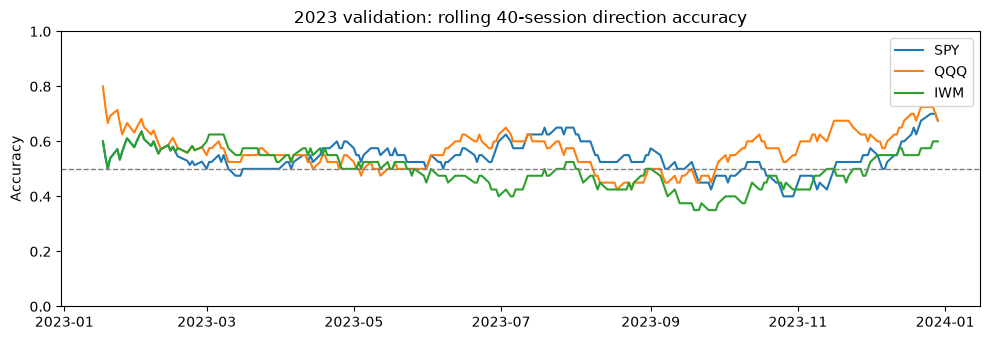

In [6]:
validation_detail = pd.DataFrame(selected_info['summary']).T
validation_detail = validation_detail.loc[[x for x in validation_detail.index if x.startswith('test_prequential')]]
display(validation_detail[['n', 'accuracy', 'majority_baseline', 'brier', 'up_rate']].round(4))
fig, ax = plt.subplots(figsize=(10, 3.5))
for ticker in TARGETS:
    part = selected_frame[(selected_frame.split == 'test_prequential') & (selected_frame.ticker == ticker)]
    rolling = part.correct.rolling(40, min_periods=10).mean()
    ax.plot(pd.to_datetime(part.label_date), rolling, label=ticker)
ax.axhline(.5, color='gray', ls='--', lw=1)
ax.set(title='2023 validation: rolling 40-session direction accuracy', ylabel='Accuracy', ylim=(0,1))
ax.legend(); fig.tight_layout(); plt.show()

## 5. Choose your own direction thresholds

Edit the three values in the next cell. `prob_up >= threshold` predicts **up**; a smaller threshold predicts up more often. Each threshold must be between 0 and 1. The values start at 0.50, but you can set a different value for each ETF (for example, 0.45 for SPY and 0.55 for IWM).

The table immediately below checks your choices on the **2023 validation period**. The probabilities and Brier scores do not change when you change a decision threshold. After running the notebook once, you can edit this cell and rerun **this cell plus the threshold report and accuracy-plot cells in section 6** to compare thresholds without training the model again. Use the forward-period result only for evaluation; repeatedly changing thresholds after seeing it would overfit that period.

In [7]:
# EDIT THESE VALUES, then rerun this cell and the threshold report cell in section 6.
chosen_thresholds = {
    'SPY': 0.50,
    'QQQ': 0.50,
    'IWM': 0.50,
}
assert set(chosen_thresholds) == set(TARGETS), 'Provide one threshold for each ETF.'
assert all(0.0 <= float(chosen_thresholds[t]) <= 1.0 for t in TARGETS), 'Thresholds must be in [0, 1].'

validation_only = selected_frame[selected_frame.split == 'test_prequential']
threshold_rows = []
for ticker in TARGETS:
    part = validation_only[validation_only.ticker == ticker]
    threshold = float(chosen_thresholds[ticker])
    decisions = part.prob_up.to_numpy() >= threshold
    y = part.actual_up.to_numpy()
    threshold_rows.append({
        'ticker': ticker,
        'your_threshold': threshold,
        'validation_accuracy': float((decisions == y).mean()),
        'predicted_up_rate': float(decisions.mean()),
        'majority_baseline': max(float(y.mean()), 1-float(y.mean())),
        'n': len(part),
    })
display(pd.DataFrame(threshold_rows).round(4))

,ticker,your_threshold,validation_accuracy,predicted_up_rate,majority_baseline,n
0,SPY,0.5,0.552,0.992,0.560,250
1,QQQ,0.5,0.568,1.000,0.568,250
2,IWM,0.5,0.504,0.804,0.524,250


## 6. Refit through validation; evaluate the selected settings forward

This is one evaluation using the online model settings selected above and the thresholds you entered. The model refits on labels through 2023, then makes 2024–2025 predictions sequentially. For each new day, the preceding prediction's revealed label is applied before the next forecast. The test period is not used to choose settings in this notebook. Repeatedly changing settings after viewing this table would make the reported result optimistic.

The first cell in this section fits the selected model. The next cell evaluates your thresholds. Once fitted, rerun only the threshold cell in section 5 and the threshold report and accuracy-plot cells below to compare new choices without retraining.


In [8]:
final_settings = {key: value for key, value in selected_config.items() if key != 'name'}
final_fraction = training_fraction(dataset, selected_config['window'], validation_cutoff)
final_predictions, final_info = train_and_replay(
    dataset, output_dir / 'selected_forward', train_fraction=final_fraction,
    batch_size=64, device='cpu', **final_settings,
)
forward = final_predictions[final_predictions.split == 'test_prequential'].copy()
print('Online updates per newly revealed label:', final_settings['online_updates'])
print('First forward label:', final_info['test_first_label_date'],
      '| Last label:', forward.label_date.max())

c:\ProgramData\Anaconda3\envs\Quant_ENV\Lib\site-packages\torch\nn\modules\transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


epoch 1/2: train BCE 0.7043


epoch 2/2: train BCE 0.7085


Online updates per newly revealed label: 1
First forward label: 2024-01-02 | Last label: 2025-03-28


In [9]:
# Rerun this cell after editing chosen_thresholds; no model retraining is needed.
thresholded_all = final_predictions.copy()
thresholded_all['your_threshold'] = thresholded_all.ticker.map(chosen_thresholds).astype(float)
thresholded_all['your_decision_up'] = (
    thresholded_all.prob_up >= thresholded_all.your_threshold
).astype(int)
thresholded_all['correct'] = (
    thresholded_all.your_decision_up == thresholded_all.actual_up
).astype(int)
threshold_forward = thresholded_all[thresholded_all.split == 'test_prequential'].copy()
report = []
for ticker in TARGETS:
    part = threshold_forward[threshold_forward.ticker == ticker]
    y, prob = part.actual_up.to_numpy(), part.prob_up.to_numpy()
    report.append({
        'ticker': ticker,
        'n': len(part),
        'your_threshold': float(chosen_thresholds[ticker]),
        'accuracy_at_0.5': float(((prob >= 0.5) == y).mean()),
        'accuracy_your_threshold': float((part.your_decision_up.to_numpy() == y).mean()),
        'majority_baseline': max(float(y.mean()), 1-float(y.mean())),
        'brier': float(np.mean((prob-y)**2)),
        'up_rate': float(y.mean()),
    })
display(pd.DataFrame(report).round(4))
threshold_forward.to_csv(output_dir / 'selected_forward' / 'your_threshold_predictions.csv', index=False)
print('Saved decisions to selected_forward/your_threshold_predictions.csv')

,ticker,n,your_threshold,accuracy_at_0.5,accuracy_your_threshold,majority_baseline,brier,up_rate
0,SPY,311,0.5,0.5402,0.5402,0.5756,0.2688,0.5756
1,QQQ,311,0.5,0.5595,0.5595,0.5723,0.2685,0.5723
2,IWM,311,0.5,0.4920,0.4920,0.5048,0.2710,0.5048


Saved decisions to selected_forward/your_threshold_predictions.csv


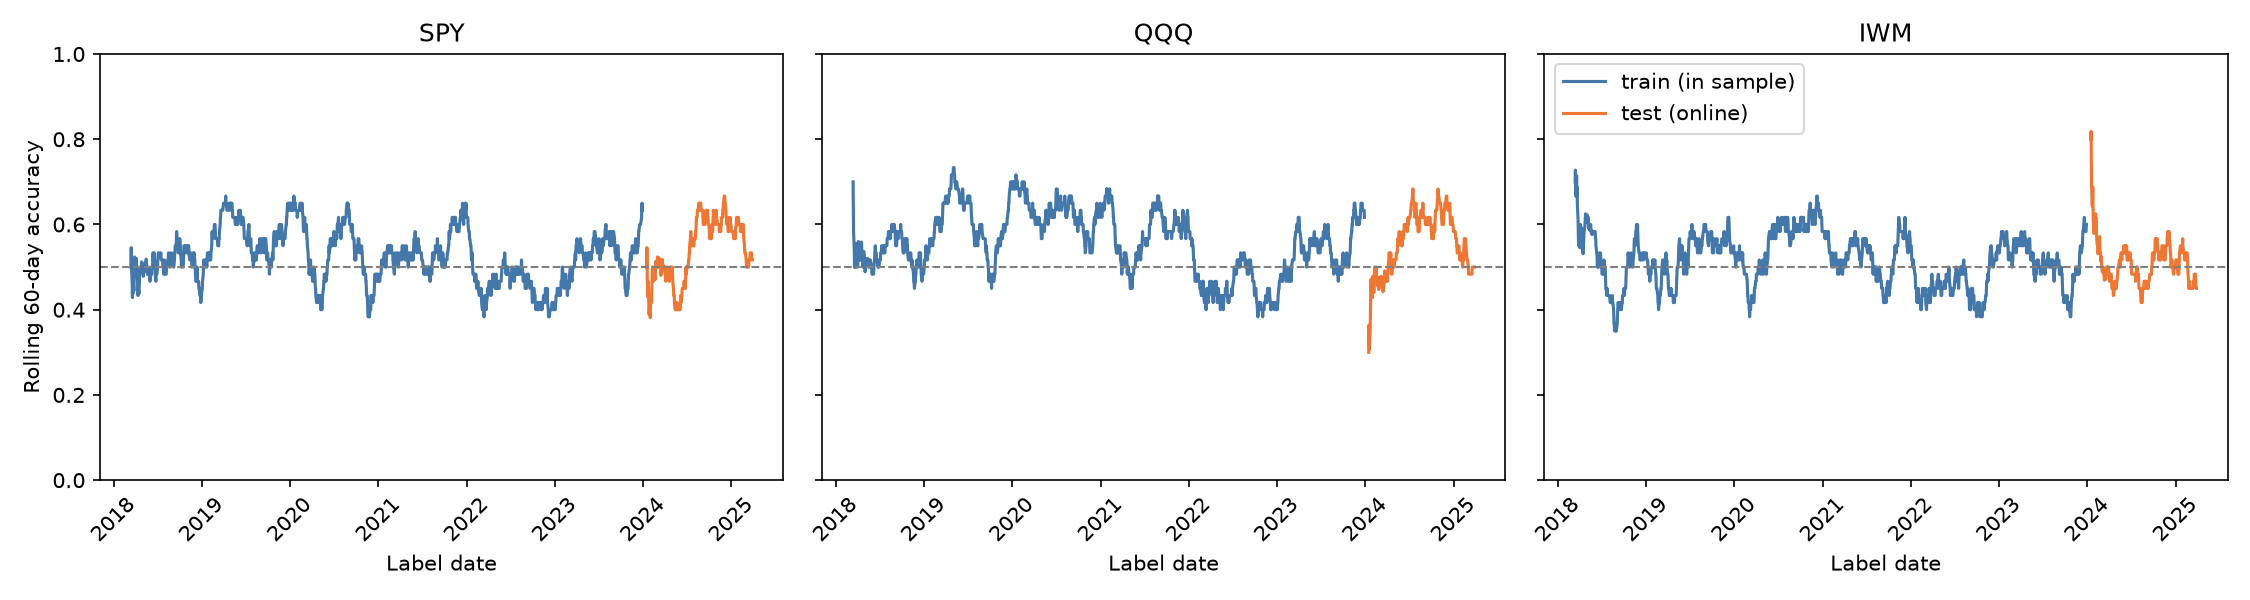

In [10]:
accuracy_plot = output_dir / 'selected_forward' / 'train_test_accuracy_user_threshold.png'
plot_accuracy(thresholded_all, accuracy_plot, rolling=60)
from IPython.display import Image as DisplayImage
display(DisplayImage(filename=str(accuracy_plot)))

### Calibration and probability diagnostics

A model can classify well while giving poor probabilities. The chart below groups forward probabilities into bins and compares the mean predicted probability with the observed up frequency. Sparse bins are unstable, so each point is labeled with its sample count. This chart diagnoses the chosen run; do not use it to revise settings and then claim an untouched forward evaluation.

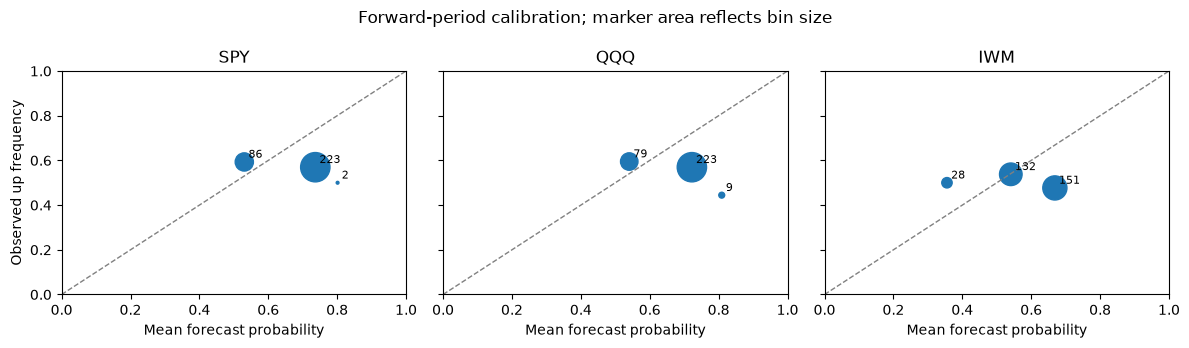

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, sharey=True)
for ax, ticker in zip(axes, TARGETS):
    part = forward[forward.ticker == ticker].copy()
    part['bin'] = pd.cut(part.prob_up, bins=np.linspace(0,1,6), include_lowest=True)
    groups = part.groupby('bin', observed=False).agg(mean_p=('prob_up','mean'), up_rate=('actual_up','mean'), n=('actual_up','size')).dropna()
    ax.plot([0,1],[0,1],ls='--',color='gray',lw=1)
    ax.scatter(groups.mean_p, groups.up_rate, s=np.maximum(groups.n,1)*2)
    for row in groups.itertuples():
        ax.annotate(str(row.n), (row.mean_p,row.up_rate), xytext=(3,3), textcoords='offset points', fontsize=8)
    ax.set(title=ticker, xlim=(0,1), ylim=(0,1), xlabel='Mean forecast probability')
axes[0].set_ylabel('Observed up frequency')
fig.suptitle('Forward-period calibration; marker area reflects bin size')
fig.tight_layout(); plt.show()

## 7. Next experiments and limits

1. Compare `online_updates=0` and `1` on the same validation dates. More updates can chase one-day noise. Keep the final period out of this choice.
2. Vary one capacity setting at a time (`window`, `hidden`, `layers`) using validation Brier. Use a new untouched period for a publishable claim.
3. For an ablation, retrain the model with one modality zeroed during **both** fitting and validation; zeroing a trained model only at inference changes its input distribution and is not a fair modality test.
4. If adding richer text or image encoders, retain the date-only news lag, filing-date checks, completed-chart rule, and chronological normalization. Document source revisions and actual release times if they become available.
5. The last FinMultiTime price observation is 2025-03-28. The saved checkpoint can update on a newly revealed label via `advance_online`, but future forecasts also need freshly synchronized prices, news, financial reports, and chart features.

Saved under `finmultitime_tuning_outputs/`: one predictions CSV, run metadata, and checkpoint per candidate; the selected forward run also has an accuracy plot. The original next-minute notebook remains separate.